In [1]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/content/financial_fraud_detection_dataset.csv")

In [ ]:
df.head()

In [ ]:
print("Display Info: \n")
print(df.info())

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.weekday
df["month"] = df["timestamp"].dt.month

In [4]:
df["is_fraud"] = df["is_fraud"].astype(int)
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


In [5]:
## Library for Data Processing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [6]:
#1 Handle Missing values
### time_since_last_spend
imputer = SimpleImputer(strategy="mean")
df[df.select_dtypes(include=np.number).columns] = imputer.fit_transform(
    df.select_dtypes(include=np.number)
)
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0.0,NaN,1.525799,-0.21,3.0,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0.0,NaN,1.525799,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0.0,NaN,1.525799,-1.78,20.0,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0.0,NaN,1.525799,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0.0,NaN,1.525799,0.79,13.0,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


In [7]:
### fraud_type
## Because fraud type does not mean anything else than is_fraud so we drop it
df = df.drop(columns=["fraud_type"])
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0.0,1.525799,-0.21,3.0,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0.0,1.525799,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0.0,1.525799,-1.78,20.0,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0.0,1.525799,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0.0,1.525799,0.79,13.0,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


In [8]:
#2 Handle categorical features
for col in df.select_dtypes(include=["object","category"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,0,2023-08-22 09:22:43.516168,774605,287290,343.78,3,7,6,1,0.0,1.525799,-0.21,3.0,0.22,2,684409,3212380,9.0,22.0,1.0,8.0
1,11,2023-08-04 01:58:02.606711,792638,841820,419.65,3,2,7,0,0.0,1.525799,-0.14,7.0,0.96,0,1616508,691787,1.0,4.0,4.0,8.0
2,22,2023-05-12 11:39:33.742963,630602,276316,2773.86,0,3,2,2,0.0,1.525799,-1.78,20.0,0.89,2,1893332,1629699,11.0,12.0,4.0,5.0
3,33,2023-10-10 06:04:43.195112,893387,243162,1666.22,0,2,5,2,0.0,1.525799,-0.60,6.0,0.37,3,198681,3819233,6.0,10.0,1.0,10.0
4,44,2023-09-24 08:09:02.700162,482844,396342,24.43,2,7,7,1,0.0,1.525799,0.79,13.0,0.27,0,220250,2829128,8.0,24.0,6.0,9.0


In [9]:
## Amount features
df["amount_per_velocity"] = df["amount"]/(df["velocity_score"] + 1)
df["amount_log"] = np.log1p(df["amount"])
df["amount_to_avg_ratio"] = df["amount"]/df.groupby("sender_account")["amount"].transform("mean")
## Frequency features
df["transaction_per_day"] = df.groupby(["sender_account","day"])["amount"].transform("count")
df["transaction_gap"] = (df.groupby("sender_account")["timestamp"].diff().dt.total_seconds().fillna(0))
## Risk features
df["is_night_transaction"] = df["hour"].between(18,24).astype(int)
df["is_weekend"] = df["day_of_week"].isin([6,8]).astype(int)
df["is_self_transfer"] = (df["sender_account"] == df["receiver_account"]).astype(int)
## Network features
df["sender_degree"] = df.groupby("sender_account")["receiver_account"].transform("nunique")
df["receiver_degree"] = df.groupby("receiver_account")["sender_account"].transform("nunique")
df["sender_total_transaction"] = df.groupby("sender_account")["amount"].transform("count")
df["receiver_total_transaction"] = df.groupby("receiver_account")["amount"].transform("count")
## Aggregation features
df["sender_avg_amount"] = df.groupby("sender_account")["amount"].transform("mean")
df["sender_std_amount"] = df.groupby("sender_account")["amount"].transform("std").fillna(0)
## Fraud features
df["sender_fraud_transaction"] = df.groupby("sender_account")["is_fraud"].transform("sum")
df["receiver_fraud_transaction"] = df.groupby("receiver_account")["is_fraud"].transform("sum")

df["sender_fraud_percentage (%)"] = (df["sender_fraud_transaction"]*100/df["sender_total_transaction"]).round(2)
df["receiver_fraud_percentage (%)"] = (df["receiver_fraud_transaction"]*100/df["receiver_total_transaction"]).round(2)

df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]] = df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]].fillna(0)
## Others
df["deviation_squared"] = df["spending_deviation_score"] ** 2
df.head(10)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month,amount_per_velocity,amount_log,amount_to_avg_ratio,transaction_per_day,transaction_gap,is_night_transaction,is_weekend,is_self_transfer,sender_degree,receiver_degree,sender_total_transaction,receiver_total_transaction,sender_avg_amount,sender_std_amount,sender_fraud_transaction,receiver_fraud_transaction,sender_fraud_percentage (%),receiver_fraud_percentage (%),deviation_squared
0,0,2023-08-22 09:22:43.516168,774605,287290,343.78,3,7,6,1,0.0,1.525799,-0.21,3.0,0.22,2,684409,3212380,9.0,22.0,1.0,8.0,85.945000,5.842907,2.468726,1,0.0,0,0,0,5,6,5,6,139.254000,134.787138,0.0,1.0,0.00,16.67,0.0441
1,11,2023-08-04 01:58:02.606711,792638,841820,419.65,3,2,7,0,0.0,1.525799,-0.14,7.0,0.96,0,1616508,691787,1.0,4.0,4.0,8.0,52.456250,6.041801,2.493439,1,0.0,0,0,0,6,5,6,5,168.301667,164.970814,0.0,0.0,0.00,0.00,0.0196
2,22,2023-05-12 11:39:33.742963,630602,276316,2773.86,0,3,2,2,0.0,1.525799,-1.78,20.0,0.89,2,1893332,1629699,11.0,12.0,4.0,5.0,132.088571,7.928356,4.639393,1,0.0,0,0,0,7,4,7,4,597.892857,990.233513,0.0,0.0,0.00,0.00,3.1684
3,33,2023-10-10 06:04:43.195112,893387,243162,1666.22,0,2,5,2,0.0,1.525799,-0.60,6.0,0.37,3,198681,3819233,6.0,10.0,1.0,10.0,238.031429,7.418913,2.399640,1,0.0,0,0,0,4,5,4,5,694.362500,807.082916,0.0,0.0,0.00,0.00,0.3600
4,44,2023-09-24 08:09:02.700162,482844,396342,24.43,2,7,7,1,0.0,1.525799,0.79,13.0,0.27,0,220250,2829128,8.0,24.0,6.0,9.0,1.745000,3.235930,0.066287,1,0.0,0,1,0,4,6,4,6,368.550000,652.920482,0.0,0.0,0.00,0.00,0.6241
5,55,2023-11-20 17:49:27.940971,479284,149224,58.77,2,0,0,0,0.0,1.525799,-1.63,19.0,0.40,1,329846,336904,17.0,20.0,0.0,11.0,2.938500,4.090504,0.273622,1,0.0,0,0,0,4,3,4,3,214.785000,189.468315,0.0,0.0,0.00,0.00,2.6569
6,66,2023-11-11 11:15:41.359248,655396,167088,59.51,1,6,1,2,0.0,1.525799,-2.62,1.0,0.68,1,4103369,2098299,11.0,11.0,5.0,11.0,29.755000,4.102809,0.157046,1,0.0,0,0,0,8,6,8,6,378.933750,522.199782,0.0,0.0,0.00,0.00,6.8644
7,77,2023-06-09 06:32:36.945101,3389,754378,29.79,2,0,2,0,0.0,1.525799,-0.48,5.0,0.37,0,4626450,139490,6.0,9.0,4.0,6.0,4.965000,3.427190,0.058371,1,0.0,0,0,0,7,8,7,8,510.358571,463.430235,1.0,0.0,14.29,0.00,0.2304
8,88,2023-02-11 06:57:40.585720,868693,842817,16.00,2,7,3,3,0.0,1.525799,0.99,3.0,0.98,2,4253551,1895667,6.0,11.0,5.0,2.0,4.000000,2.833213,0.039161,1,0.0,0,0,0,7,6,7,6,408.574286,408.668338,0.0,0.0,0.00,0.00,0.9801
9,99,2023-07-13 09:25:20.560022,441974,221218,203.05,3,1,1,0,0.0,1.525799,0.59,17.0,0.45,1,606945,150667,9.0,13.0,3.0,7.0,11.280556,5.318365,0.842656,1,0.0,0,0,0,7,5,7,5,240.964286,272.706516,1.0,0.0,14.29,0.00,0.3481


In [10]:
df.drop(columns=['timestamp'], inplace=True)

In [11]:
df_majority = df[df['is_fraud'] == 0]
df_minority = df[df['is_fraud'] == 1]

df_majority_downsampled = df_majority.sample(n=2*len(df_minority), random_state=36)
df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced.shape

(538659, 39)

In [12]:
from sklearn.model_selection import train_test_split

y = df_balanced['is_fraud']
X = df_balanced.drop(columns=['is_fraud'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/8, random_state=36, stratify=y_train)
X_train.head()

,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month,amount_per_velocity,amount_log,amount_to_avg_ratio,transaction_per_day,transaction_gap,is_night_transaction,is_weekend,is_self_transfer,sender_degree,receiver_degree,sender_total_transaction,receiver_total_transaction,sender_avg_amount,sender_std_amount,sender_fraud_transaction,receiver_fraud_transaction,sender_fraud_percentage (%),receiver_fraud_percentage (%),deviation_squared
1812489,1003738,418739,429741,215.06,1,1,2,2,-4240.553492,1.00,12.0,0.22,3,1496979,2452749,16.0,1.0,6.0,1.0,16.543077,5.375556,0.538776,1,-1.526599e+07,0,1,0,5,6,5,6,399.164000,752.353433,0.0,0.0,0.00,0.00,1.0000
4337326,3781059,336473,756995,1261.79,0,5,0,1,-3887.919654,-0.28,13.0,0.60,1,1018973,269161,3.0,18.0,3.0,5.0,90.127857,7.141079,3.677062,1,-1.399651e+07,0,0,0,6,9,6,9,343.151667,460.218645,1.0,1.0,16.67,11.11,0.0784
2292504,1531755,850110,650409,87.30,0,6,0,3,-5558.457235,0.84,8.0,0.66,3,4021451,2869131,23.0,10.0,0.0,4.0,9.700000,4.480740,0.348244,1,-2.001045e+07,1,0,0,8,1,8,1,250.686250,379.568053,4.0,1.0,50.00,100.00,0.7056
4564107,4030518,412055,673083,8.39,2,3,7,3,-4094.274384,-0.48,12.0,0.78,2,1114243,3641374,5.0,5.0,0.0,6.0,0.645385,2.239645,0.034171,1,-1.473939e+07,0,0,0,8,9,8,9,245.526250,170.642460,0.0,0.0,0.00,0.00,0.2304
4499707,3959678,477033,94321,1417.79,0,3,6,3,1540.065888,0.59,3.0,0.77,0,3060142,1315248,3.0,19.0,3.0,10.0,354.447500,7.257560,2.013041,1,5.544237e+06,0,0,0,4,2,4,2,704.302500,695.945537,0.0,0.0,0.00,0.00,0.3481


In [13]:
len(X_train), len(y_train), len(X_test), len(y_test)

(377061, 377061, 107732, 107732)

In [14]:
from xgboost import XGBClassifier

scale_pos_weight = y_train[y_train==1].count() / y_train[y_train==0].count()
xgb_model = XGBClassifier(n_estimators=300,
                        objective='binary:logistic',
                        tree_method='hist',
                        max_depth=12,
                        learning_rate=0.05,
                        reg_lambda=3.6,
                        reg_alpha=3.6,
                        scale_pos_weight=scale_pos_weight,
                        eval_metric=['aucpr'],
                        verbosity=2,
                        subsample=0.8,
                        device='cuda',
                        n_jobs=-1)

print("Training model ...")
eval_set=[(X_train, y_train),(X_val, y_val)]
xgb_model.fit(X_train, y_train,
             eval_set=eval_set,
             verbose=50)
print("Training complete!")

Training model ...
[16:28:50] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (377061, 38, 14328318).
[16:28:50] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (53866, 38, 2046908).
[0]	validation_0-aucpr:0.96110	validation_1-aucpr:0.96030
[50]	validation_0-aucpr:0.97872	validation_1-aucpr:0.97508
[100]	validation_0-aucpr:0.98748	validation_1-aucpr:0.97548
[150]	validation_0-aucpr:0.99329	validation_1-aucpr:0.97526
[200]	validation_0-aucpr:0.99699	validation_1-aucpr:0.97465
[250]	validation_0-aucpr:0.99905	validation_1-aucpr:0.97403
[299]	validation_0-aucpr:0.99975	validation_1-aucpr:0.97347
Training complete!


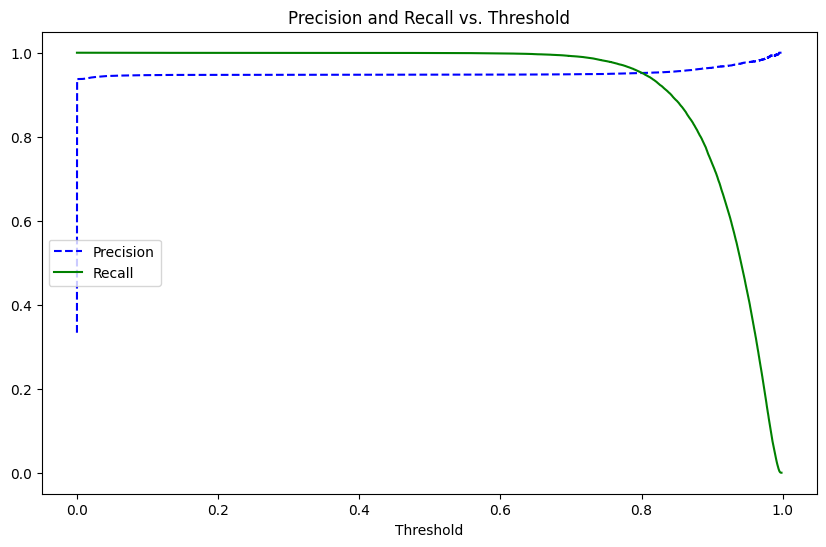

In [15]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.legend(loc='center left')
plt.title('Precision and Recall vs. Threshold')
plt.show()

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X, y, test_size=0.2, random_state=36, stratify=y)

# Standard Scaler is needed for MLP model
scaler = StandardScaler()
scaler.fit(X_train_mlp)
X_train_mlp, X_test_mlp = scaler.transform(X_train_mlp), scaler.transform(X_test_mlp)

mlp_model = MLPClassifier(hidden_layer_sizes=(36, 72, 36),
                          learning_rate='adaptive',
                          learning_rate_init=0.01,
                          max_iter=30,
                          random_state=36,
                          early_stopping=True,
                          validation_fraction=0.1,
                         verbose=True)

print("Training...")
mlp_model.fit(X=X_train_mlp, y=y_train_mlp)
print("Train completed!")

Training...
Iteration 1, loss = 0.08314299
Validation score: 0.977096
Train completed!


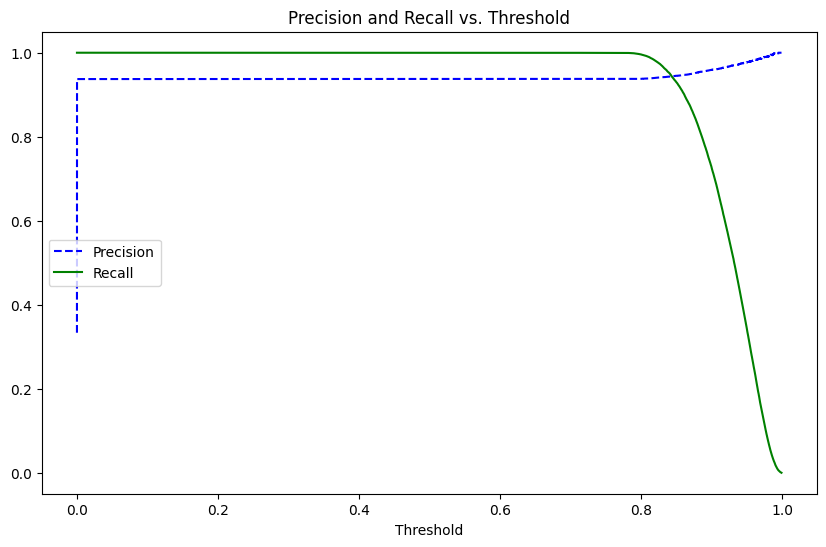

In [17]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba = mlp_model.predict_proba(X_test_mlp)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_mlp, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.legend(loc='center left')
plt.title('Precision and Recall vs. Threshold')
plt.show()

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

#Evaluate
y_pred_proba = mlp_model.predict_proba(X_test_mlp)[:, 1]
print(y_pred_proba)
print(classification_report(y_test_mlp, (y_pred_proba > 0.5).astype(int)))
print(f"AP: {average_precision_score(y_test_mlp, y_pred_proba):.4f}")

[9.34046903e-01 1.55908838e-15 8.81645768e-01 ... 9.81458816e-01
 2.82684142e-17 8.58486212e-25]
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     71821
         1.0       0.94      1.00      0.97     35911

    accuracy                           0.98    107732
   macro avg       0.97      0.98      0.98    107732
weighted avg       0.98      0.98      0.98    107732

AP: 0.9695


In [19]:
import joblib
import os

model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

# Save the XGBoost model
model_path = os.path.join(model_dir, 'xgb_fraud_detector.joblib')
joblib.dump(xgb_model, model_path)
print(f'Model saved to: {model_path}')

# Verify it loads correctly
loaded_model = joblib.load(model_path)
sample_score = loaded_model.predict_proba(X_test[:5])[:, 1]
print(f'Verification — fraud scores for 5 test samples: {sample_score.round(4)}')
print('Model saved and verified successfully!')

Model saved to: models/xgb_fraud_detector.joblib
Verification — fraud scores for 5 test samples: [9.156e-01 1.000e-04 9.223e-01 8.722e-01 1.000e-04]
Model saved and verified successfully!
